================================================================================
### Exploratory Data Analysis (EDA) - ImageArg Dataset (Gun Control)
================================================================================

This notebook explores the textual component of the ImageArg dataset focusing on the "gun control" topic. The goal is to understand dataset structure, label distribution, and key textual characteristics (tweets).

In [14]:
#Libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from nltk.corpus import stopwords
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from itertools import combinations


nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
sns.set_theme(palette="pastel")

#Path
path = "/workspace/dzuniga/multimodal-argmining/"
os.chdir(path)


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/dzuniga/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
#Load Dataset
df = pd.read_csv(f"{path}/data/new_dataset_annotated.csv")


train_df = df[df["split"]=="train"]
dev_df = df[df["split"]=="dev"]
test_df = df[df["split"]=="test"]

df.head()

,tweet_id,tweet_url,tweet_text,split,stance
0,1081597919726190592,https://t.co/CgjpeQjHaB,Democrats propose bill that would allow aborti...,dev,oppose
1,1213868223663419392,https://t.co/GcrqwHvnFc,“Abortion supporters try to blur the distincti...,dev,oppose
2,1040359568407183361,https://t.co/f3igsZqKry,Pro-abortion media refuses to cover stories li...,dev,oppose
3,1030187200359682048,https://t.co/bkv66OAeZ6,God is bringing healing both to those who have...,dev,oppose
4,1269277873376034816,https://t.co/WIT9ermcKr,Facebook Censors Pro-Life Ad Showing How Abort...,dev,oppose


### Columns Description

- **tweet_id**: Unique identifier of the tweet (string or integer).
- **tweet_url**: Original link to the tweet (not always needed for analysis).
- **tweet_text**: The text content of the tweet (our main focus for EDA).
- **stance**: Annotated argumentative stance towards gun control (support, oppose)
- **persuasiveness**: Whether the image (attached to the tweet) contributes to the persuasiveness of the argument (yes/no).
- **split**: Dataset split for experiments(train, val, test).

In [16]:
#Dataset shape
print("Dataset shape:", df.shape)

#Shape per splits
print(df['split'].value_counts())

#Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Dataset shape: (2314, 5)
split
train    1814
test      300
dev       200
Name: count, dtype: int64

Missing values per column:
tweet_id      0
tweet_url     0
tweet_text    0
split         0
stance        0
dtype: int64


In [4]:
#Since we only want to analyze the train data for future preprocessing techniques or feature engineering 
#we will filter it

train_df = df[df['split'] == 'train'].copy()


Stance value counts (dev):
 stance
oppose     132
support     68
Name: count, dtype: int64


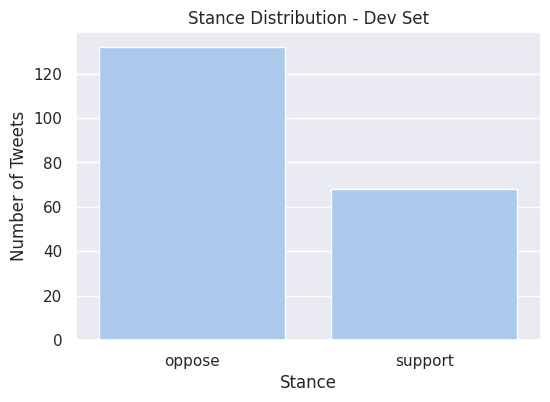


Stance value counts (test):
 stance
oppose     190
support    110
Name: count, dtype: int64


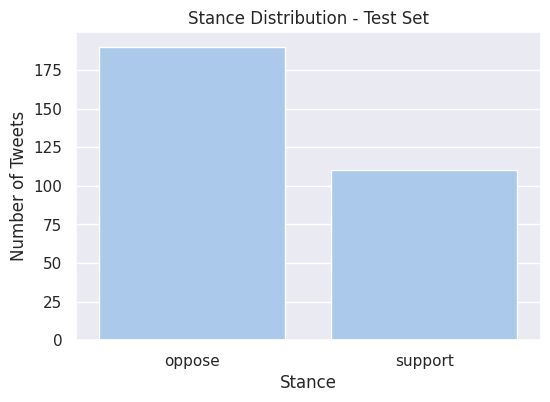


Stance value counts (train):
 stance
oppose     1139
support     675
Name: count, dtype: int64


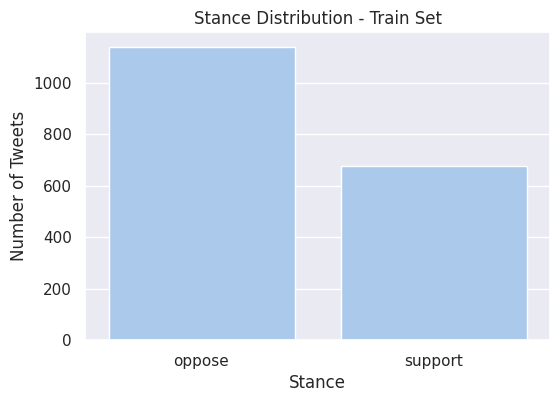

In [21]:
#Stance distribution

for split_name in df["split"].unique():
    
    subset = df[df["split"] == split_name]
    
    stance_counts = subset["stance"].value_counts()
    
    print(f"\nStance value counts ({split_name}):\n", stance_counts)
    
    plt.figure(figsize=(6,4))
    sns.barplot(x=stance_counts.index, y=stance_counts.values)
    plt.title(f"Stance Distribution - {split_name.capitalize()} Set")
    plt.ylabel("Number of Tweets")
    plt.xlabel("Stance")
    plt.show()


**Stance:** The dataset is relatively balanced, with 475 tweets supporting gun control and 448 opposing it.
**Persuasiveness:** Most images do not contribute to persuasiveness, with 672 labeled no versus 251 labeled yes.

/tmp/ipykernel_1034094/711665694.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['char_count'] = train_df['tweet_text'].apply(len)
/tmp/ipykernel_1034094/711665694.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['word_count'] = train_df['tweet_text'].apply(lambda x: len(str(x).split()))


Character count statistics:
count    1814.000000
mean      238.442117
std        67.127031
min        51.000000
25%       191.000000
50%       260.500000
75%       298.000000
max       335.000000
Name: char_count, dtype: float64

Word count statistics:
count    1814.000000
mean       33.687982
std        11.623374
min         4.000000
25%        25.000000
50%        36.000000
75%        43.000000
max        58.000000
Name: word_count, dtype: float64


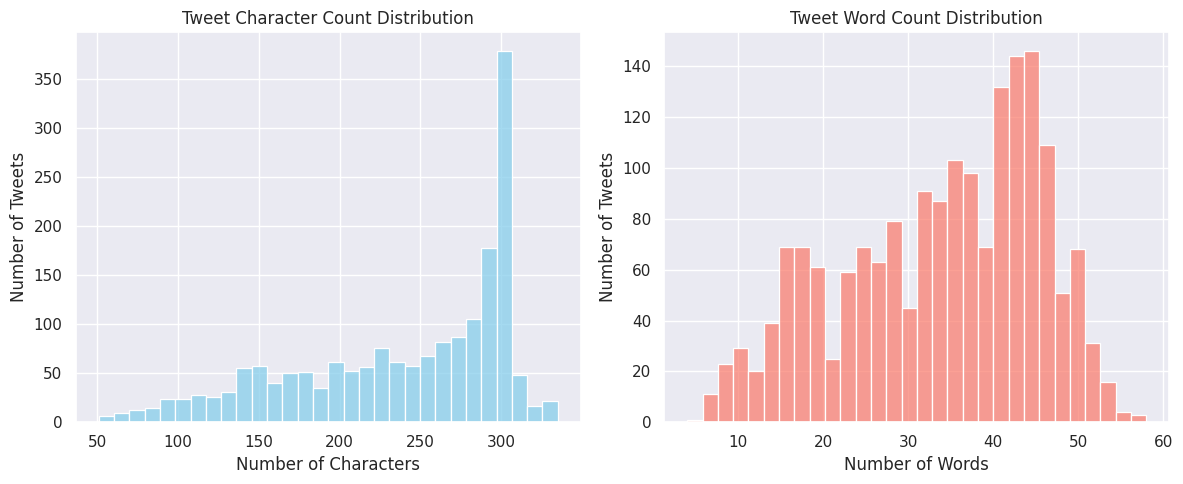

In [22]:
#Tweet Length 

#Add auxiliar lenght columns 
train_df['char_count'] = train_df['tweet_text'].apply(len)
train_df['word_count'] = train_df['tweet_text'].apply(lambda x: len(str(x).split()))


print("Character count statistics:")
print(train_df['char_count'].describe())
print("\nWord count statistics:")
print(train_df['word_count'].describe())

#Histograms
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(train_df['char_count'], bins=30, color='skyblue')
plt.title("Tweet Character Count Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")

plt.subplot(1,2,2)
sns.histplot(train_df['word_count'], bins=30, color='salmon')
plt.title("Tweet Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tweets")

plt.tight_layout()
plt.show()


**Characters:** Tweets are moderately long, averaging ~238 characters, with most between 205 and 299 characters. Minimum length is 52, maximum 335.

**Words:** Tweets contain on average ~36 words, with the majority ranging from 28 to 44 words. Minimum is 6 words, maximum 58.

/tmp/ipykernel_1034094/1141770505.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['clean_text'] = train_df['tweet_text'].apply(clean_text)
/tmp/ipykernel_1034094/1141770505.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['clean_text_nostop'] = train_df['clean_text'].apply(remove_stopwords)
/tmp/ipykernel_1034094/1141770505.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legen

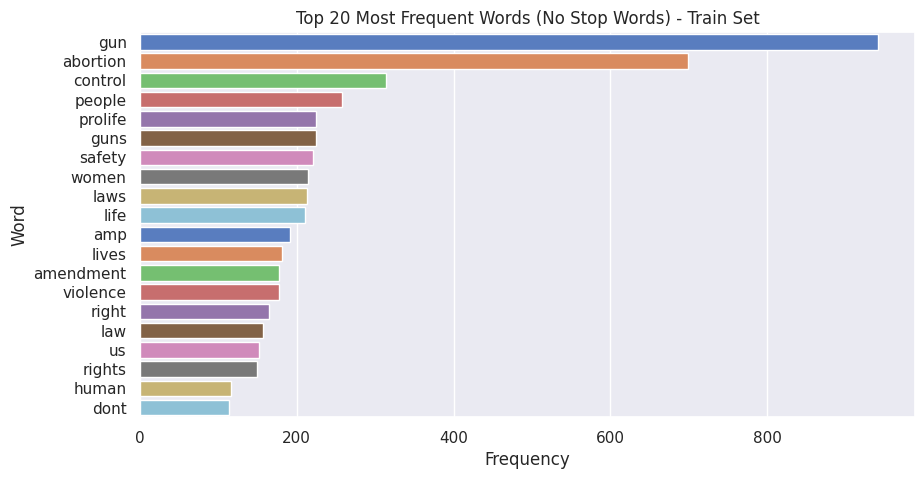

In [23]:
#Most Frequent Words - Train Set

#Text Cleaning simple function 
def clean_text(text):
    text = str(text).lower()    
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  
    text = re.sub(r"@\w+", "", text)            
    text = re.sub(r"#\w+", "", text)            
    text = re.sub(r"[^a-z\s]", "", text)       
    return text

#Clean Texts
train_df['clean_text'] = train_df['tweet_text'].apply(clean_text)


#Remove stopwords function
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

#Remove stopwrods
train_df['clean_text_nostop'] = train_df['clean_text'].apply(remove_stopwords)


all_words_nostop = " ".join(train_df['clean_text_nostop']).split()
word_freq_nostop = Counter(all_words_nostop)

# Top 20 most common words without stop words
most_common_words_nostop = word_freq_nostop.most_common(20)

#Plot top 20 words
words_nostop, counts_nostop = zip(*most_common_words_nostop)
plt.figure(figsize=(10,5))
sns.barplot(x=list(counts_nostop), y=list(words_nostop), palette="muted")
plt.title("Top 20 Most Frequent Words (No Stop Words) - Train Set")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

/tmp/ipykernel_1034094/3721432163.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="pastel")


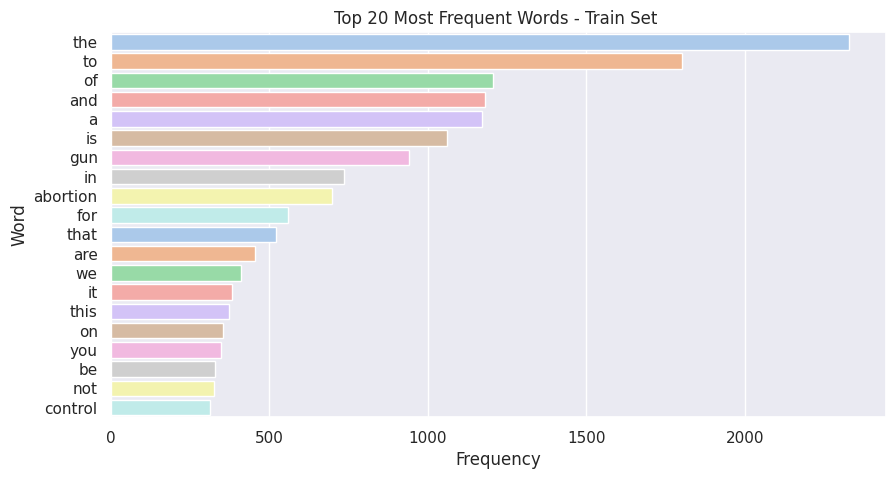

In [24]:

#Tokenize and count words
all_words = " ".join(train_df['clean_text']).split()
word_freq = Counter(all_words)

#Top 20 most common words
most_common_words = word_freq.most_common(20)

words, counts = zip(*most_common_words)
plt.figure(figsize=(10,5))
sns.barplot(x=list(counts), y=list(words), palette="pastel")
plt.title("Top 20 Most Frequent Words - Train Set ")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()


/tmp/ipykernel_1034094/2653690632.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(ngrams), palette="pastel")


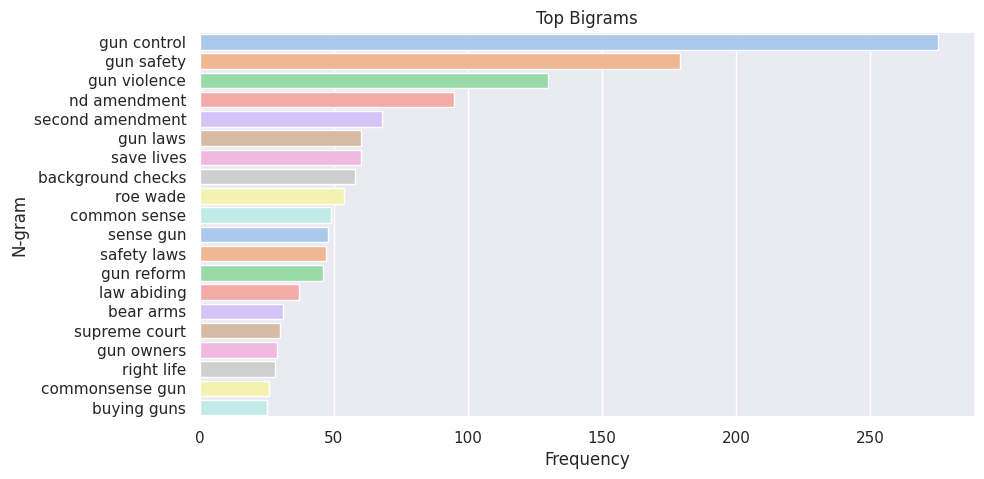

/tmp/ipykernel_1034094/2653690632.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(ngrams), palette="pastel")


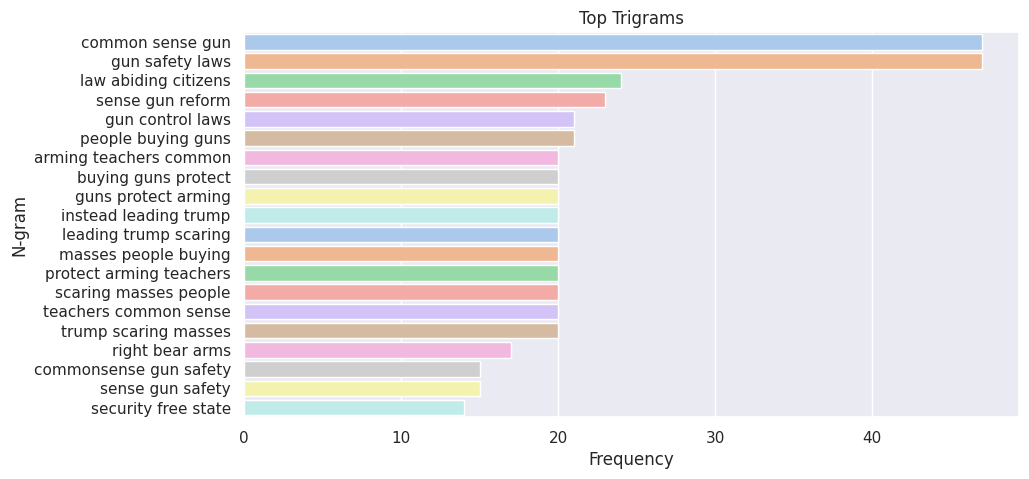

In [25]:
#Bigram and Trigram Analysis (without stop words)


#Bigram analysis
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
X_bigrams = bigram_vectorizer.fit_transform(train_df['clean_text_nostop'])
bigram_counts = X_bigrams.sum(axis=0).A1
bigram_features = bigram_vectorizer.get_feature_names_out()
bigram_freq = dict(zip(bigram_features, bigram_counts))

#Trigram analysis
trigram_vectorizer = CountVectorizer(ngram_range=(3,3), stop_words='english')
X_trigrams = trigram_vectorizer.fit_transform(train_df['clean_text_nostop'])
trigram_counts = X_trigrams.sum(axis=0).A1
trigram_features = trigram_vectorizer.get_feature_names_out()
trigram_freq = dict(zip(trigram_features, trigram_counts))


#Top 20 n-grams
top_bigrams = Counter(bigram_freq).most_common(20)
top_trigrams = Counter(trigram_freq).most_common(20)

#Plots
ngrams, counts = zip(*top_bigrams)
plt.figure(figsize=(10,5))
sns.barplot(x=list(counts), y=list(ngrams), palette="pastel")
plt.title("Top Bigrams")
plt.xlabel("Frequency")
plt.ylabel("N-gram")
plt.show()

ngrams, counts = zip(*top_trigrams)
plt.figure(figsize=(10,5))
sns.barplot(x=list(counts), y=list(ngrams), palette="pastel")
plt.title("Top Trigrams")
plt.xlabel("Frequency")
plt.ylabel("N-gram")
plt.show()


/tmp/ipykernel_1034094/907526444.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts1), y=list(ngrams1), palette="Blues_r")


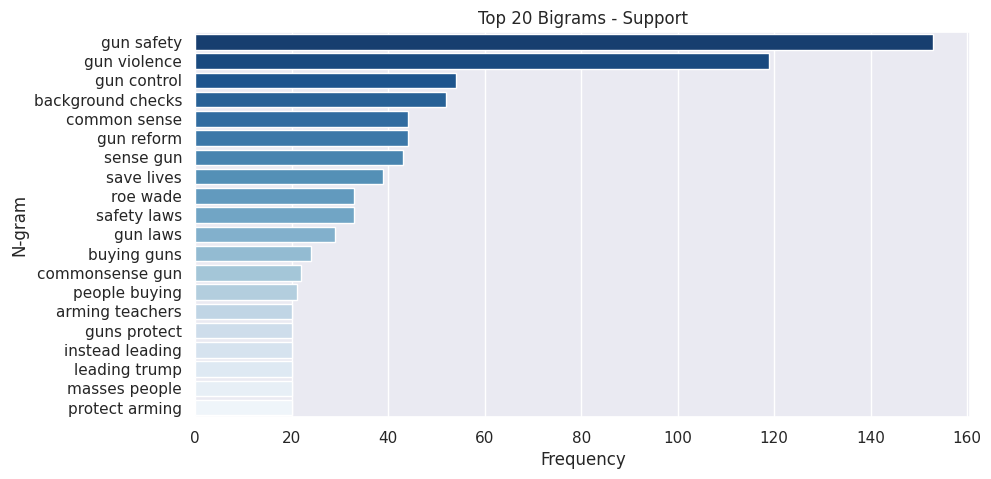

/tmp/ipykernel_1034094/907526444.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts1), y=list(ngrams1), palette="Reds_r")


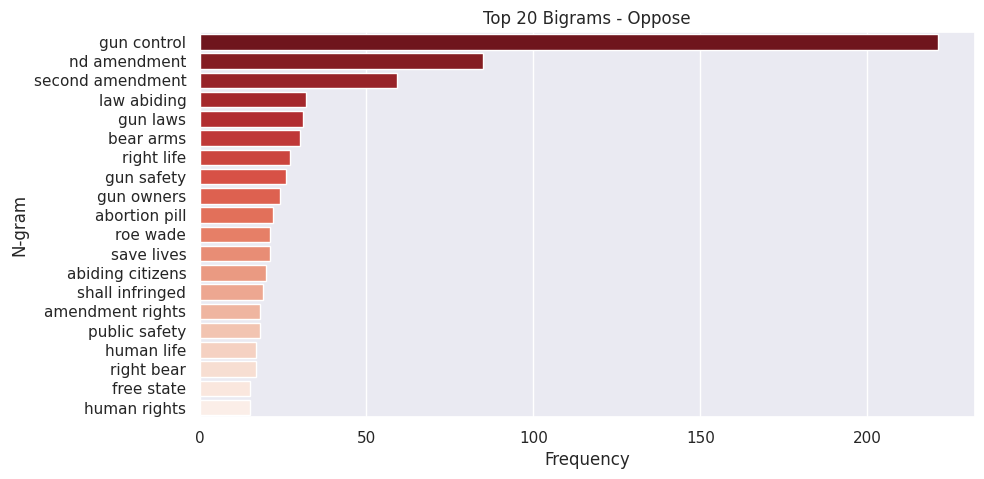

In [26]:
# N-gram Comparison by Stance - Train Set (without stop words)

#Split by stance
support_texts = train_df[train_df['stance']=='support']['clean_text_nostop']
oppose_texts = train_df[train_df['stance']=='oppose']['clean_text_nostop']

# Function to compute n-gram frequencies
def get_ngram_freq(text_series, ngram=2,stop_words='english'):
    vectorizer = CountVectorizer(ngram_range=(ngram,ngram), stop_words=stop_words)
    X = vectorizer.fit_transform(text_series)
    counts = X.sum(axis=0).A1
    features = vectorizer.get_feature_names_out()
    return dict(zip(features, counts))

#Compute bigram frequencies
support_bigrams = get_ngram_freq(support_texts, ngram=2)
oppose_bigrams = get_ngram_freq(oppose_texts, ngram=2)


#Plots
#Support
support = Counter(support_bigrams).most_common(20)
ngrams1, counts1 = zip(*support)
plt.figure(figsize=(10,5))
sns.barplot(x=list(counts1), y=list(ngrams1), palette="Blues_r")
plt.title(f"Top 20 Bigrams - Support")
plt.xlabel("Frequency")
plt.ylabel("N-gram")
plt.show()

#Oppose
oppose = Counter(oppose_bigrams).most_common(20)
ngrams1, counts1 = zip(*oppose)
plt.figure(figsize=(10,5))
sns.barplot(x=list(counts1), y=list(ngrams1), palette="Reds_r")
plt.title(f"Top 20 Bigrams - Oppose")
plt.xlabel("Frequency")
plt.ylabel("N-gram")
plt.show()

### Hastags

In [27]:
#Hashtag Analysis
def extract_hashtags(text):
    return re.findall(r'#(\w+)', str(text).lower())

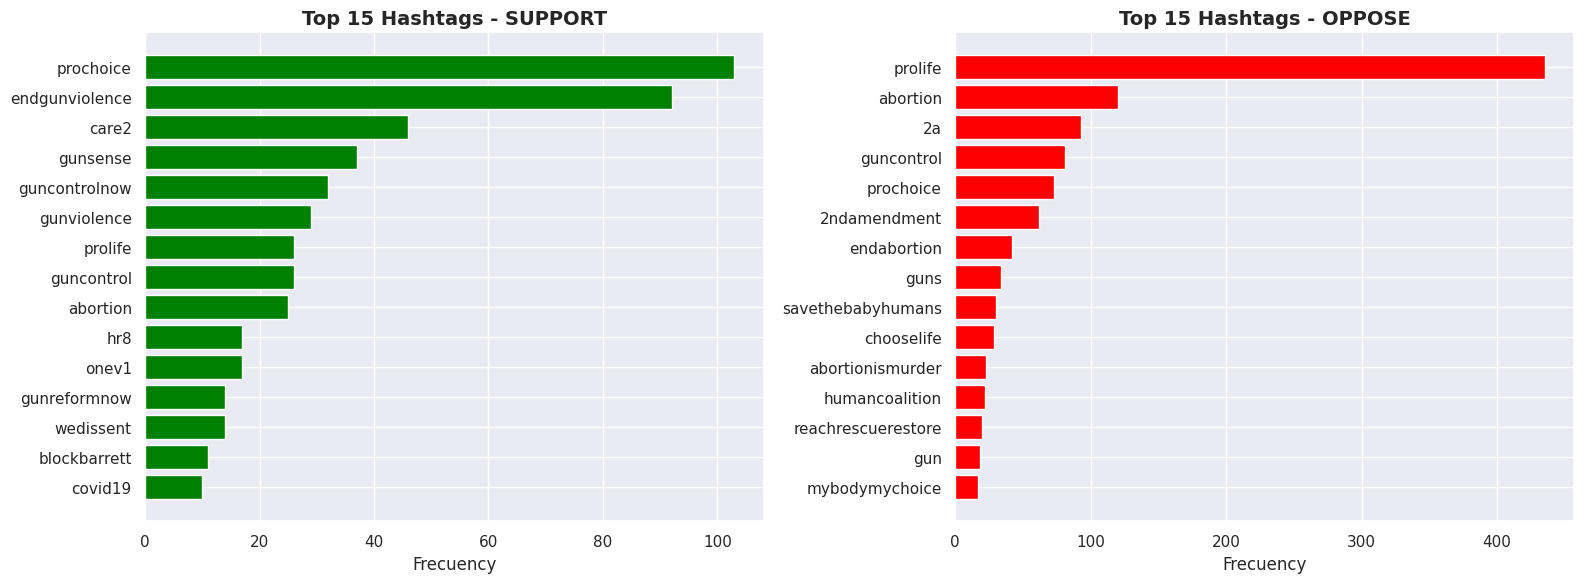

In [28]:
df['hashtags'] = df['tweet_text'].apply(extract_hashtags)
df['num_hashtags'] = df['hashtags'].apply(len)

support_hashtags = []
oppose_hashtags = []

for idx, row in df.iterrows():
    if row['stance'] == 'support':
        support_hashtags.extend(row['hashtags'])
    elif row['stance'] == 'oppose':
        oppose_hashtags.extend(row['hashtags'])

support_counter = Counter(support_hashtags)
oppose_counter = Counter(oppose_hashtags)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Support
sup_tags, sup_counts = zip(*support_counter.most_common(15))
axes[0].barh(sup_tags, sup_counts, color='green')
axes[0].set_xlabel('Frecuency', fontsize=12)
axes[0].set_title('Top 15 Hashtags - SUPPORT', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Oppose
opp_tags, opp_counts = zip(*oppose_counter.most_common(15))
axes[1].barh(opp_tags, opp_counts, color='red')
axes[1].set_xlabel('Frecuency', fontsize=12)
axes[1].set_title('Top 15 Hashtags - OPPOSE', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [29]:
# Co-occurrence Analysis of Hashtags
cooccurrence = Counter()

for hashtags_list in df['hashtags']:
    if len(hashtags_list) >= 2:
        for pair in combinations(sorted(hashtags_list), 2):
            cooccurrence[pair] += 1
print("Pairs of Hashtags that MOST co-occur:")
for (h1, h2), count in cooccurrence.most_common(15):
    print(f"  #{h1} + #{h2}: {count} veces")

print(f"\nTweets with at least 1 hashtag: {(df['num_hashtags'] > 0).sum()} "
        f"({(df['num_hashtags'] > 0).mean():.1%})")
print(f"Average of hashtags per tweet: {df['num_hashtags'].mean():.2f}")
print(f"Max number of hastags in a Tweet: {df['num_hashtags'].max()}")

# Por stance
print("\nBy Stance:")
for stance in ['support', 'oppose']:
    stance_df = df[df['stance'] == stance]
    print(f"  {stance.upper()}:")
    print(f"    - Tweets with hashtags: {(stance_df['num_hashtags'] > 0).mean():.1%}")
    print(f"    - Average hashtags/tweet: {stance_df['num_hashtags'].mean():.2f}")

Pairs of Hashtags that MOST co-occur:
  #abortion + #prolife: 106 veces
  #prochoice + #prolife: 72 veces
  #abortion + #prochoice: 55 veces
  #endabortion + #prolife: 40 veces
  #abortion + #endabortion: 29 veces
  #prolife + #savethebabyhumans: 28 veces
  #chooselife + #prolife: 27 veces
  #endabortion + #savethebabyhumans: 26 veces
  #abortion + #savethebabyhumans: 25 veces
  #care2 + #care2: 23 veces
  #abortionismurder + #prolife: 22 veces
  #humancoalition + #prolife: 22 veces
  #humancoalition + #savethebabyhumans: 21 veces
  #2a + #guns: 21 veces
  #humancoalition + #reachrescuerestore: 20 veces

Tweets with at least 1 hashtag: 1443 (62.4%)
Average of hashtags per tweet: 1.83
Max number of hastags in a Tweet: 17

By Stance:
  SUPPORT:
    - Tweets with hashtags: 68.3%
    - Average hashtags/tweet: 1.68
  OPPOSE:
    - Tweets with hashtags: 58.9%
    - Average hashtags/tweet: 1.91


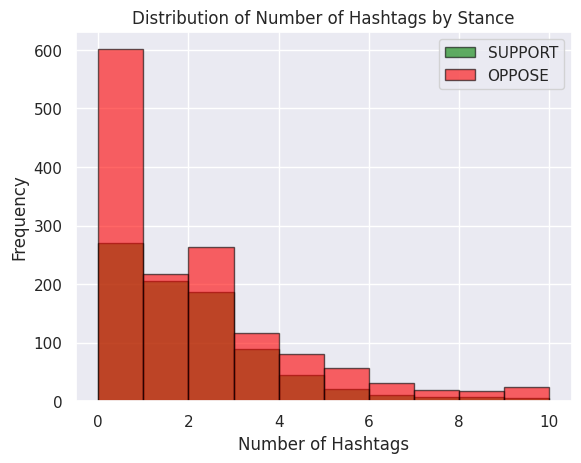

In [30]:
#Oppose
oppose = Counter(oppose_bigrams).most_common(20)
ngrams1, counts1 = zip(*oppose)

for stance, color in [('support', 'green'), ('oppose', 'red')]:
    stance_data = df[df['stance'] == stance]['num_hashtags']
    plt.hist(stance_data, bins=range(0, 11), alpha=0.6,
             label=stance.upper(), color=color, edgecolor='black')

plt.title("Distribution of Number of Hashtags by Stance")
plt.xlabel("Number of Hashtags")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### URLs

In [31]:

def extract_urls(text):
    url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
    return re.findall(url_pattern, str(text))

In [32]:
df['urls'] = df['tweet_text'].apply(extract_urls)
    

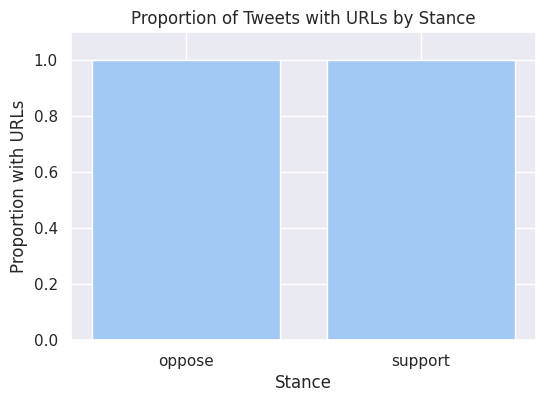

,stance,has_url
0,oppose,1.0
1,support,1.0


In [33]:
# Crear columna booleana: ¿tiene URL?
df['has_url'] = df['urls'].apply(lambda x: len(x) > 0)  # detecta si hay algo en la lista

# Calcular proporciones por stance
url_distribution = df.groupby('stance')['has_url'].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(url_distribution['stance'], url_distribution['has_url'])
plt.title("Proportion of Tweets with URLs by Stance")
plt.ylabel("Proportion with URLs")
plt.xlabel("Stance")    
plt.ylim(0, 1.1)
plt.show()

url_distribution


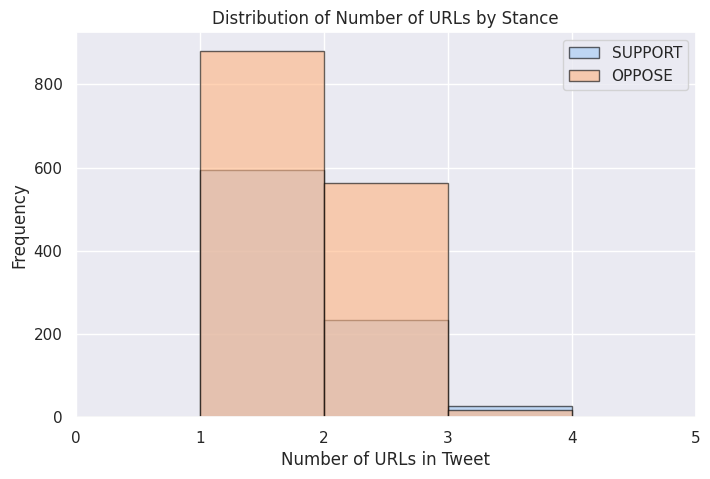

In [34]:
# Contar número de URLs
df['num_urls'] = df['urls'].apply(lambda x: len(x))

plt.figure(figsize=(8,5))
for stance, color in [('support', 'green'), ('oppose', 'red')]:
    stance_data = df[df['stance'] == stance]['num_urls']
    plt.hist(stance_data, bins=range(0, 6), alpha=0.6, label=stance.upper(), edgecolor='black')

plt.title("Distribution of Number of URLs by Stance")
plt.xlabel("Number of URLs in Tweet")
plt.ylabel("Frequency")
plt.legend()
plt.xlim(0, 5)
plt.show()